量子卷积神经网络
==============================

在这个演示中，我们实现了*量子卷积神经网络*（Quanvolutional Neural Network），这是一个最初由Henderson et al. (2019)提出的量子机器学习模型[1]。

引言
------------

### 经典卷积

*卷积神经网络*（CNN）是经典机器学习中的一个标准模型，特别适合处理图像。这种模型基于*卷积层*的概念，不是用全局函数处理全部输入数据，而是应用局部卷积。

如果输入是一张图像，那么小的局部区域会被一个核（kernel）依次处理。对每个区域获得的结果通常与单个输出像素的不同通道相关联。所有输出像素的结合产生了一个新的类似图像的对象，这个对象可以由额外的层进一步处理。

### 量子卷积

同样的概念也可以扩展到量子变分电路中。一种可能的方法如下：

1. 输入图像的一个小区域（例如 $2 \times 2$ 的正方形）被嵌入到一个量子电路中。在这个演示中，这是通过应用于初始处于基态的量子位上的参数化旋转来实现的。
2. 在系统上执行与酉矩阵 $U$ 相关的量子计算。该酉矩阵可以由变分量子电路产生，或者更简单地，由随机电路产生。
3. 最终对量子系统进行测量，获得一系列经典的期望值。测量结果也可以像参考文献[1]中提出的那样进行经典后处理，但为简单起见，在这个演示中我们直接使用原始的期望值。
4. 类似于经典卷积层，每个期望值被映射到单个输出像素的不同通道。
5. 通过在不同区域重复相同的程序，可以扫描整个输入图像，产生一个结构为多通道图像的输出对象。
6. 量子卷积可以由更多的量子层或经典层跟随。

与经典卷积的主要区别在于量子电路可以生成高度复杂的核，其计算至少在原则上可能是经典不可解的。

在本教程中，我们将用量子机器学习库deepquantum探索量子卷积神经网络（QCNN）在8*8的Digits手写数字数据集上的训练效果。


<div style="text-align:center">
    <img src="./images/3_9_0001.png" alt="Local Image">
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>二维数据集的量子-经典混合卷积模型架构图
    </p>
</div>

通用设置
-------------

In [1]:
# 使用以下代码加载本次实验所需的工具包：
import torch
from torch import nn
from torchvision import datasets, transforms
import random
import os
import numpy as np
import deepquantum as dq
import torch.optim as optim
from sklearn import datasets
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from matplotlib import pyplot as plt
import pandas as pd

加载数据集
============================

本次实验需要使用Digits 数据集，Digits 数据集是一个手写数字的数据集，包含了1797个样本。每个样本都是一个8x8的像素矩阵，代表一个手写数字的图像。这个数据集有10个分类，代表了“0，1，2，…，9”这10个数字。每个样本对应的特征向量的维数为64，对应了每组数据的8*8个像素点。

这个数据集可以通过Python的sklearn库加载。

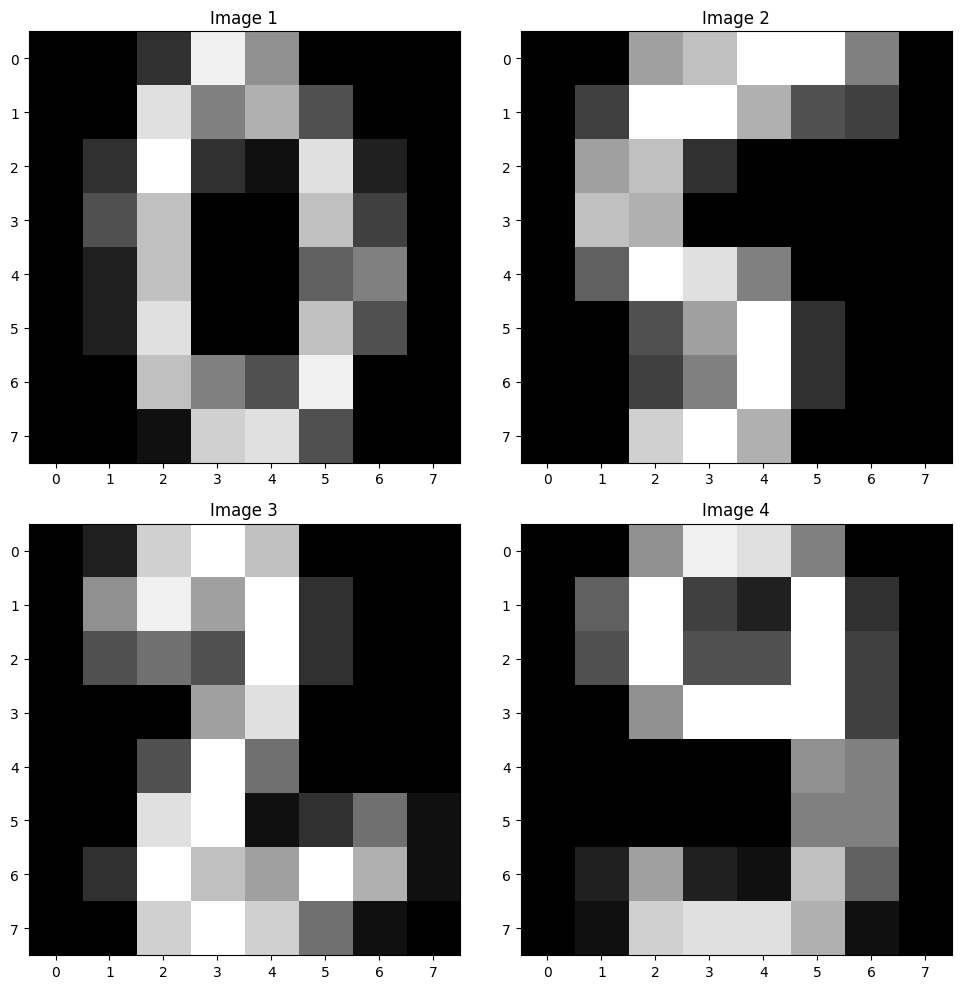

In [2]:
#Digits dataset数据集
# 加载数据
digits = datasets.load_digits()
data = digits.images
targets = digits.target

# 划分训练集和临时集
train_data, temp_data, train_targets, temp_targets = train_test_split(data, targets, test_size=0.4, random_state=1024)

# 划分测试集和验证集
test_data, val_data, test_targets, val_targets = train_test_split(temp_data, temp_targets, test_size=0.5, random_state=1024)

# 转换为Tensor
train_data = torch.tensor(train_data, dtype=torch.float32)
val_data = torch.tensor(val_data, dtype=torch.float32)
test_data = torch.tensor(test_data, dtype=torch.float32)

train_targets = torch.tensor(train_targets, dtype=torch.int64)
val_targets = torch.tensor(val_targets, dtype=torch.int64)
test_targets = torch.tensor(test_targets, dtype=torch.int64)

# 创建TensorDataset
train_dataset = TensorDataset(train_data, train_targets)
val_dataset = TensorDataset(val_data, val_targets)
test_dataset = TensorDataset(test_data, test_targets)

# 创建DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

# 画出数据集的示例
# 设置画布大小
plt.figure(figsize=(10, 10))

# 打印四张图片
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(train_data[i], cmap='gray')
    plt.title(f'Image {i+1}')

plt.tight_layout()
plt.show()

画出Digits 数据集的部分图片，你可以尝试保存切分好的数据集，方便之后直接调用。也可以进一步尝试用其他数据集训练模型。

模型定义
============
接下来我们用量子机器学习库deepquantum定义随机参数化量子卷积线路。

In [3]:
# 随机参数化量子卷积线路
class RandomParameterizedQuantumConvolutionLayer(nn.Module):
    def __init__(self, nqubit, num_circuits, seed:int=1024):
        super(RandomParameterizedQuantumConvolutionLayer, self).__init__()
        random.seed(seed)
        self.nqubit = nqubit
        self.cirs = nn.ModuleList([self.circuit(nqubit) for _ in range(num_circuits)])
        self.num_circuits=num_circuits
    def circuit(self, nqubit):
        singlegate_list = ['rx', 'ry', 'rz', 's', 't', 'p', 'u3']  #可调节
        doublegate_list = ['rxx', 'ryy', 'rzz', 'swap', 'cnot', 'cp', 'ch', 'cu', 'ct', 'cz']  #可调节
        cir = dq.QubitCircuit(nqubit)
        cir.rxlayer(encode=True)  # 对原论文的量子线路结构并无影响，只是做了一个数据编码的操作
        cir.barrier()
        for iter in range(3):   #可调节
            for i in range(nqubit):
                singlegate = random.choice(singlegate_list)
                getattr(cir, singlegate)(i)
            control_bit, target_bit = random.sample(range(0, nqubit - 1), 2)
            doublegate = random.choice(doublegate_list)
            if doublegate[0] in ['r', 's']:
                getattr(cir, doublegate)([control_bit, target_bit])
            else:
                getattr(cir, doublegate)(control_bit, target_bit)
            cir.barrier()

        for j in range(self.nqubit):
            cir.observable(j)
        return cir

    def forward(self, x):
        x_unflod = x.unfold(2, 2, 2)  #在指定维度上对输入张量进行滑动窗口操作。这里，2是要操作的维度，2是滑动窗口的大小，另一个2是滑动窗口的步长。这个函数会返回一个新的张量，其中包含了原始张量中所有大小为3x3的子张量。#可调节
        x_reshape = x_unflod.reshape(-1, self.nqubit)
        exps = []
        for cir in self.cirs:
            cir(x_reshape)
            exp = cir.expectation()
            exps.append(exp)
        exps = torch.stack(exps, dim=1)
        exps = exps.reshape(x.shape[0], self.num_circuits, x.shape[-1], x.shape[-1])
        return exps

# 基于随机参数化量子卷积线路的混合网络架构：
class QuantumRandomPQCCNN(nn.Module):
    def __init__(self):
        super(QuantumRandomPQCCNN, self).__init__()
        self.conv = nn.Sequential(
            RandomParameterizedQuantumConvolutionLayer(nqubit=4, num_circuits=3, seed=1024),   # num_circuits=3代表我们在Quanv1层只用了3个量子卷积  #可调节
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=1),

        )
        self.fc = nn.Sequential(
            nn.Linear(108, 1024),  #可调节
            nn.Dropout(0.05),
            nn.Linear(1024, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)
        return x

模型训练
=========================
我们首先初始化模型的一个实例，然后用已经通过量子卷积预处理的数据集对其进行训练和验证。

In [4]:
#设置随机种子
def seed_torch(seed=1024):

    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_torch(1024)

In [5]:
# 计算准确率
def calculate_score(y_true, y_preds):
    # 将模型预测结果转为概率分布
    preds_prob = torch.softmax(y_preds, dim=1)
    # 获得预测的类别（概率最高的一类）
    preds_class = torch.argmax(preds_prob, dim=1)
    # 计算准确率
    correct = (preds_class == y_true).float()
    accuracy = correct.sum() / len(correct)
    return accuracy.cpu().numpy()

In [10]:
def train_model(model, criterion, optimizer, train_loader, valid_loader, num_epochs, device):
    """
    训练和验证模型。

    Args:
        model (torch.nn.Module): 要训练的模型。
        criterion (torch.nn.Module): 损失函数。
        optimizer (torch.optim.Optimizer): 优化器。
        train_loader (torch.utils.data.DataLoader): 训练数据加载器。
        valid_loader (torch.utils.data.DataLoader): 验证数据加载器。
        num_epochs (int): 训练的epoch数。

    Returns:
        model (torch.nn.Module): 训练后的模型。
    """

    model.train()
    train_loss_list = []
    valid_loss_list = []
    train_acc_list = []
    valid_acc_list = []
    for epoch in tqdm(range(num_epochs)):
        # 训练阶段
        train_loss = 0.0
        train_acc = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_acc += calculate_score(labels, outputs)
        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        # 验证阶段
        model.eval()
        valid_loss = 0.0
        valid_acc = 0.0
        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valid_loss += loss.item()
                valid_acc += calculate_score(labels, outputs)
        valid_loss /= len(valid_loader)
        valid_acc /= len(valid_loader)
        if epoch%20==0:
            print(f'Train Loss: {train_loss:.3f} Train Acc: {train_acc:.3f} '
                f'Valid Loss: {valid_loss:.3f} Valid Acc: {valid_acc:.3f}')
        train_loss_list.append(train_loss)
        valid_loss_list.append(valid_loss)
        train_acc_list.append(train_acc)
        valid_acc_list.append(valid_acc)
    metrics = {'epoch': list(range(1, num_epochs + 1)),
                'train_acc': train_acc_list,
                'valid_acc': valid_acc_list,
                'train_loss': train_loss_list,
                'valid_loss': valid_loss_list}
    return model, metrics

def test_model(model, test_loader, device):
    model.eval()
    test_acc = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            test_acc += calculate_score(labels, outputs)
        test_acc /= len(test_loader)
        print(f'Test Acc: {test_acc:.3f}')
    return test_acc



In [11]:
num_epochs = 100 # 训练轮数为100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed_torch(1024)   # 重新设置随机种子
model = QuantumRandomPQCCNN()
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.001)  # 添加正则化项
optim_model, metrics = train_model(model, criterion, optimizer, train_loader, valid_loader, num_epochs, device)

  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:00<01:09,  1.42it/s]

Train Loss: 2.305 Train Acc: 0.112 Valid Loss: 2.281 Valid Acc: 0.142


 21%|██        | 21/100 [00:13<00:51,  1.53it/s]

Train Loss: 1.730 Train Acc: 0.576 Valid Loss: 1.763 Valid Acc: 0.562


...

 61%|██████    | 61/100 [00:39<00:25,  1.54it/s]

Train Loss: 1.039 Train Acc: 0.699 Valid Loss: 1.143 Valid Acc: 0.685


 81%|████████  | 81/100 [00:52<00:12,  1.54it/s]

Train Loss: 0.893 Train Acc: 0.730 Valid Loss: 0.965 Valid Acc: 0.734


100%|██████████| 100/100 [01:05<00:00,  1.53it/s]


结果展示
=======

最终，我们可以绘制出随着训练次数增加，测试准确率和测试损失的变化情况。

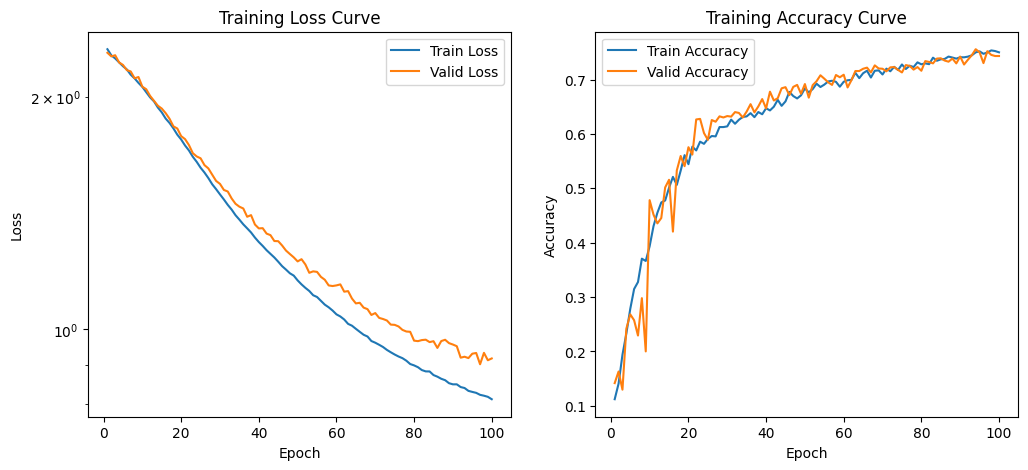

In [12]:
epoch = metrics['epoch']
train_loss = metrics['train_loss']
valid_loss = metrics['valid_loss']
train_acc = metrics['train_acc']
valid_acc = metrics['valid_acc']

# 创建图和Axes对象
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 绘制训练损失曲线
ax1.plot(epoch, train_loss, label='Train Loss')
ax1.plot(epoch, valid_loss, label='Valid Loss')
ax1.set_title('Training Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_yscale('log')
ax1.legend()

# 绘制训练准确率曲线
ax2.plot(epoch, train_acc, label='Train Accuracy')
ax2.plot(epoch, valid_acc, label='Valid Accuracy')
ax2.set_title('Training Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

参考文献
==========

[1] Henderson M, Shakya S, Pradhan S, et al. Quanvolutional neural networks: powering image recognition with quantum circuits[J]. Quantum Machine Intelligence, 2020, 2(1): 2.